In [ ]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pandas as pd
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10

In [2]:
import time
from collections import deque
from typing import Dict, Tuple

import gymnasium as gym
import numpy as np
import torch
from torch import Tensor

from sample_factory.algo.learning.learner import Learner
from sample_factory.algo.sampling.batched_sampling import preprocess_actions
from sample_factory.algo.utils.action_distributions import argmax_actions
from sample_factory.algo.utils.env_info import extract_env_info
from sample_factory.algo.utils.make_env import make_env_func_batched
from sample_factory.algo.utils.misc import ExperimentStatus
from sample_factory.algo.utils.rl_utils import make_dones, prepare_and_normalize_obs
from sample_factory.algo.utils.tensor_utils import unsqueeze_tensor
from sample_factory.cfg.arguments import load_from_checkpoint
from sample_factory.huggingface.huggingface_utils import generate_model_card, generate_replay_video, push_to_hf
from sample_factory.model.actor_critic import create_actor_critic
from sample_factory.model.model_utils import get_rnn_size
from sample_factory.utils.attr_dict import AttrDict
from sample_factory.utils.typing import Config, StatusCode
from sample_factory.utils.utils import debug_log_every_n, experiment_dir, log

/home/fr/fr_lr554/.conda/envs/env/lib/python3.10/site-packages/deepmind_lab/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/fr/fr_lr554/.conda/envs/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import datetime, pathlib, json,  pandas as pd, torch

def _ensure_parent(path: pathlib.Path):
    path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
# from sample_factory.arguments import load_from_checkpoint
cfg_filename='/work/classic/fr_lr554-TrainSpace/spectral_radius/train_dir/hipposlam/RNNFixedSequence44_/00_RNNFixedSequence44_see_1111/config.json'
with open(cfg_filename, "r") as json_file:
    json_params = json.load(json_file)
    log.warning("Loading existing experiment configuration from %s", cfg_filename)
    loaded_cfg = AttrDict(json_params)

# # override the parameters in config file with values passed from command line
# for key, value in cfg.cli_args.items():
#     if key in loaded_cfg and loaded_cfg[key] != value:
#         log.debug("Overriding arg %r with value %r passed from command line", key, value)
#         loaded_cfg[key] = value

# # incorporate extra CLI parameters that were not present in JSON file
# for key, value in vars(cfg).items():
#     if key not in loaded_cfg:
#         log.debug("Adding new argument %r=%r that is not in the saved config file!", key, value)
#         loaded_cfg[key] = value

[2026-01-27 14:09:30,426][1390054] Loading existing experiment configuration from /work/classic/fr_lr554-TrainSpace/spectral_radius/train_dir/hipposlam/RNNFixedSequence44_/00_RNNFixedSequence44_see_1111/config.json


In [5]:
cfg=loaded_cfg

In [6]:
cfg['train_dir']="/work/classic/fr_lr554-TrainSpace/spectral_radius/train_dir/hipposlam/RNNFixedSequence44_"
cfg['encoder_conv_architecture']='resnet'

In [7]:
cfg['core_name']

'BypassFixedRNN'

In [8]:
cfg = load_from_checkpoint(cfg)

[2026-01-27 14:09:46,082][1390054] Loading existing experiment configuration from /work/classic/fr_lr554-TrainSpace/spectral_radius/train_dir/hipposlam/RNNFixedSequence44_/00_RNNFixedSequence44_see_1111/config.json


In [9]:
REDUCED_ACTION_SET = (
    (0, 0, 0, 1, 0, 0, 0),  # Forward
    # (0, 0, 0, -1, 0, 0, 0),  # Backward
    (0, 0, -1, 0, 0, 0, 0),  # Strafe Left
    (0, 0, 1, 0, 0, 0, 0),  # Strafe Right
    # (-20, 0, 0, 0, 0, 0, 0),  # Look Left
    # (20, 0, 0, 0, 0, 0, 0),  # Look Right
    (-20, 0, 0, 1, 0, 0, 0),  # Look Left + Forward
    (20, 0, 0, 1, 0, 0, 0),  # Look Right + Forward
    # (0, 0, 0, 0, 1, 0, 0),  # Fire.
)
action_space = gym.spaces.Discrete(len(REDUCED_ACTION_SET))
observation_space = gym.spaces.Dict(
    obs=gym.spaces.Box(low=0, high=255, shape=(72, 96, 3), dtype=np.uint8)
)

In [10]:
cfg['core_name']

'BypassFixedRNN'

In [11]:
actor_critic = create_actor_critic(cfg,observation_space, action_space)

[2026-01-27 14:09:49,195][1390054] RunningMeanStd input shape: (72, 96, 3)
[2026-01-27 14:09:49,199][1390054] RunningMeanStd input shape: (1,)
[2026-01-27 14:09:49,216][1390054] Num input channels: 72
[2026-01-27 14:09:49,228][1390054] Convolutional layer output size: 384
[2026-01-27 14:09:49,249][1390054] get out size called: {self.core_output_size}


In [12]:
dict(actor_critic.named_parameters()).keys()

dict_keys(['encoder.encoders.obs.conv_head.0.weight', 'encoder.encoders.obs.conv_head.0.bias', 'encoder.encoders.obs.conv_head.2.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.2.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.2.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.2.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.3.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.3.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.3.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.3.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.4.weight', 'encoder.encoders.obs.conv_head.4.bias', 'encoder.encoders.obs.conv_head.6.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.6.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.6.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.6.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.7.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.7.res_block_core.1.bi

In [13]:
for n, p in actor_critic.named_parameters():
    if "weight_hh" in n or "weight_ih" in n or ".rnn." in n:
        print(n, tuple(p.shape), p.requires_grad)


core.core.weight_ih_l0 (3447, 256) True
core.core.weight_hh_l0 (3447, 1149) True


In [14]:
cfg['core_name']

'BypassFixedRNN'

In [15]:
print(type(actor_critic.core))
print(type(actor_critic.core.core))



<class 'sample_factory.model.core.ModelCoreRNN'>
<class 'torch.nn.modules.rnn.GRU'>


In [16]:
import torch.nn as nn

for name, m in actor_critic.named_modules():
    if isinstance(m, (nn.RNN, nn.GRU, nn.LSTM)):
        print(name, type(m), "input", m.input_size, "hidden", m.hidden_size, "bias", m.bias)

core.core <class 'torch.nn.modules.rnn.GRU'> input 256 hidden 1149 bias True


In [19]:
dict_keys(['encoder.encoders.obs.conv_head.0.weight', 'encoder.encoders.obs.conv_head.0.bias', 'encoder.encoders.obs.conv_head.2.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.2.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.2.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.2.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.3.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.3.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.3.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.3.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.4.weight', 'encoder.encoders.obs.conv_head.4.bias', 'encoder.encoders.obs.conv_head.6.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.6.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.6.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.6.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.7.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.7.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.7.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.7.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.8.weight', 'encoder.encoders.obs.conv_head.8.bias', 'encoder.encoders.obs.conv_head.10.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.10.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.10.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.10.res_block_core.3.bias', 'encoder.encoders.obs.conv_head.11.res_block_core.1.weight', 'encoder.encoders.obs.conv_head.11.res_block_core.1.bias', 'encoder.encoders.obs.conv_head.11.res_block_core.3.weight', 'encoder.encoders.obs.conv_head.11.res_block_core.3.bias', 'encoder.encoders.obs.mlp_layers.0.weight', 'encoder.encoders.obs.mlp_layers.0.bias', 'core.core.weight_ih_l0', 'core.core.weight_hh_l0', 'core.core.bias_ih_l0', 'core.core.bias_hh_l0', 'decoder.mlp.0.weight', 'decoder.mlp.0.bias', 'decoder.mlp.2.weight', 'decoder.mlp.2.bias', 'critic_linear.weight', 'critic_linear.bias', 'action_parameterization.distribution_linear.weight', 'action_parameterization.distribution_linear.bias'])

NameError: name 'dict_keys' is not defined

In [47]:
x = dict(actor_critic.named_parameters())['core.core.weight_hh_l0'].detach().cpu().numpy()

In [48]:
x

array([[ 0.00844539, -0.01317561,  0.01908117, ...,  0.01138885,
         0.00347139, -0.00467193],
       [-0.01029176, -0.01093736,  0.02368798, ...,  0.00157479,
        -0.00638978,  0.00745655],
       [ 0.00794383, -0.0267887 ,  0.00902813, ..., -0.00938473,
         0.01615479,  0.01055948],
       ...,
       [-0.02773977, -0.00316421, -0.0174446 , ..., -0.00429083,
        -0.00721282,  0.01816678],
       [-0.01902681, -0.01234359,  0.01290933, ...,  0.0139086 ,
         0.01547165, -0.02248986],
       [-0.0193914 , -0.01226983, -0.01672717, ...,  0.01992506,
         0.02471127, -0.00789966]], dtype=float32)

In [49]:
y = dict(actor_critic.named_parameters())['core.core.bias_ih_l0'].detach().cpu().numpy()

In [50]:
y

array([ 0.00047206,  0.00076298,  0.00300704, ..., -0.01407854,
        0.01359613,  0.02664289], dtype=float32)

In [51]:
U,s,V=np.linalg.svd(x)

In [52]:
x.shape

(3447, 1149)

In [ ]:
3447 - 1149 - 1149

1149

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

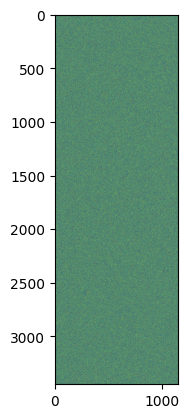

In [ ]:
plt.imshow(x)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

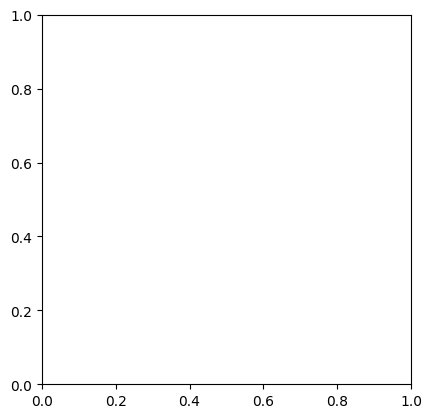

In [ ]:
plt.imshow(dict(actor_critic.named_parameters())['core.core.weight_ih_l0'])